# Explore linear fluence  law 

## Zhou 2023: https://www.sciencedirect.com/science/article/pii/S1369800123001919
## Shen 2010


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit


In [2]:

class fluencePowerLaw:
    def __init__(self, c_0, phi_0):
        self.c_0 = c_0
        self.phi_0 = phi_0

    def eval(self, fluence):
        return 1 - self.c_0 * np.log(1 + fluence/self.phi_0)
    
    def plot(self, min_fluence, max_fluence):
        fluences = np.range(min_fluence, max_fluence)
        return plt.plot(self.eval(fluences))


In [4]:
# Fit model to csv of data
# Required columns: 'fluence (e/cm^2)', 'V_oc', 'I_SC', 'P_max'
# TODO-TD: we could make a dataclass to wrap a dataframe?
# Required vs optional columns

df = pd.read_csv("../data/Wang2021.csv")

def model(x, c, x0):
    return 1 - c * np.log(1 + x / x0)

wang_2021_results = {}
for (ptype, energy), grp in df.groupby(['particle type', 'energy (MeV)']):
    
    x = grp['fluence (e/cm^2)'].values
    if len(x) > 2:
        print(f"{ptype} {energy} MeV")
        ks = ['V_oc', 'I_SC', 'P_max']

        wang_2021_results[f'{energy} MeV {ptype} GaInP/GaAs/Ge'] = dict.fromkeys(ks)

        for name in ks:
            y = grp[name].values
            # initial guesses matter here — x0 must stay > 0 (log domain)
            # so give curve_fit bounds to keep it well-behaved
            p0 = [1.0, 1.0]              # [c, x0] starting guess
            bounds = ([-np.inf, 1e-8], [np.inf, np.inf])  # x0 > 0

            popt, pcov = curve_fit(model, x, y, p0=p0, bounds=bounds)
            c_fit, x0_fit = popt
            perr = np.sqrt(np.diag(pcov))  # 1-sigma parameter errors

            print(f" {name} c  = {c_fit:.6g} ± {perr[0]:.2g}")
            print(f" {name} phi0 = {x0_fit:.6g} ± {perr[1]:.2g}")

            # goodness of fit
            y_pred = model(x, *popt)
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2 = 1 - ss_res / ss_tot
            print(f"\tR squared = {r2:.4f}")
            wang_2021_results[f'{energy} MeV {ptype} GaInP/GaAs/Ge'][name] = {
                'Cp':c_fit,
                'Phi_0':x0_fit
            }


electron 1 MeV
 V_oc c  = 0.0804748 ± 0.00071
 V_oc phi0 = 1.58898e+15 ± 1.2e-20
	R squared = 0.9996
 I_SC c  = 0.0293846 ± 0.0018
 I_SC phi0 = 4.63263e+13 ± 2.1e-19
	R squared = 0.9667
 P_max c  = 0.0967031 ± 0.0034
 P_max phi0 = 3.4966e+14 ± 2.3e-19
	R squared = 0.9918


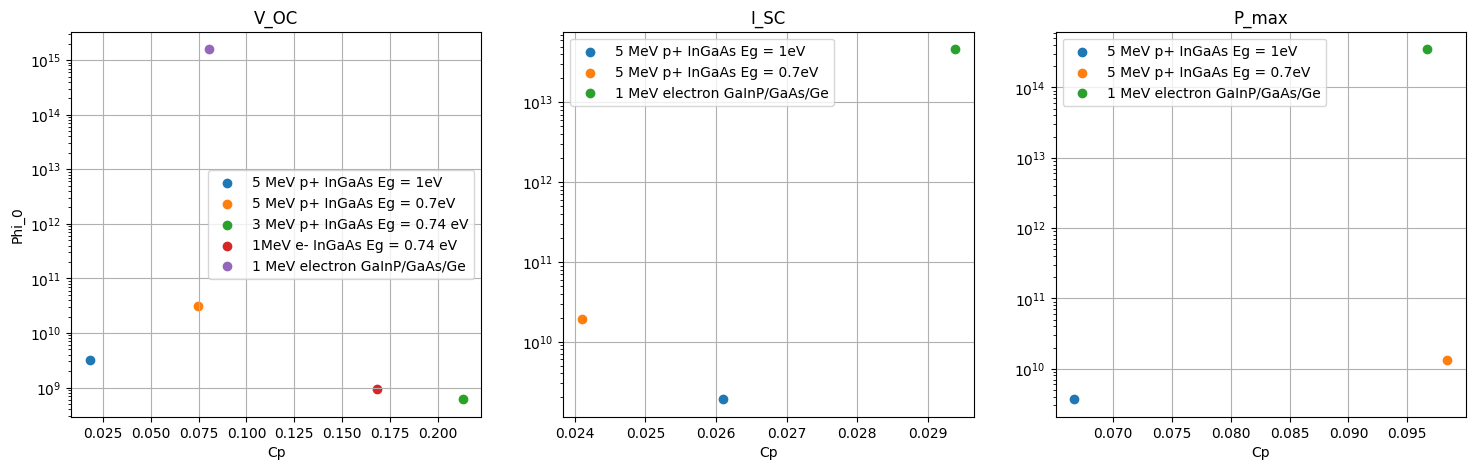

In [14]:
g, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(
    0.018,
    3.251e9,
    label='5 MeV p+ InGaAs Eg = 1eV'
)

axs[0].scatter(
    0.0747,
    3.148e10,
    label='5 MeV p+ InGaAs Eg = 0.7eV'
)
axs[0].scatter(
    0.213,
    0.61e9,
    label='3 MeV p+ InGaAs Eg = 0.74 eV'
)

axs[0].scatter(
    0.168,
    0.92e9,
    label='1MeV e- InGaAs Eg = 0.74 eV'
)

for k, v in wang_2021_results.items():
    axs[0].scatter(
        v['V_oc']['Cp'],
        v['V_oc']['Phi_0'],
        label=k
    )

axs[0].set_title('V_OC')
axs[0].set_xlabel('Cp')
axs[0].set_ylabel('Phi_0')
axs[0].set_yscale('log')
axs[0].grid()
axs[0].legend()

axs[1].scatter(
    0.0261,
    1.902e9,
    label='5 MeV p+ InGaAs Eg = 1eV'
)

axs[1].scatter(
    0.0241,
    1.904e10,
    label='5 MeV p+ InGaAs Eg = 0.7eV'
)

for k, v in wang_2021_results.items():
    axs[1].scatter(
        v['I_SC']['Cp'],
        v['I_SC']['Phi_0'],
        label=k
    )

axs[1].set_title('I_SC')
axs[1].set_xlabel('Cp')
axs[1].set_yscale('log')
axs[1].grid()
axs[1].legend()


axs[2].scatter(
    0.0667,
    3.678e9,
    label='5 MeV p+ InGaAs Eg = 1eV'
)

axs[2].scatter(
    0.0984,
    1.312e10,
    label='5 MeV p+ InGaAs Eg = 0.7eV'
)

for k, v in wang_2021_results.items():
    axs[2].scatter(
        v['P_max']['Cp'],
        v['P_max']['Phi_0'],
        label=k
    )

axs[2].set_title('P_max')
axs[2].set_xlabel('Cp')
axs[2].set_yscale('log')
axs[2].grid()
axs[2].legend()